<a href="https://colab.research.google.com/github/ongsoony8382/financial-data-programming/blob/main/%ED%83%80%EC%9D%B4%ED%83%80%EB%8B%89%ED%98%B8_%EC%83%9D%EC%A1%B4%EC%9E%90_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 학습목표
- pandas 라이브러리 심화 학습 및 활용 코딩 연습

# 학습내용
- 타이타닉호 생존의 법칙 (EDA & 시각화)


# 예제 1: 타이타닉호 생존의 법칙 (EDA & 시각화)

타이타닉호에서 "누가 살아남았는가?"를 통계적으로 분석하며 groupby와 pivot_table 활용법 학습

# 1. 데이터 로드 및 확인

- Seaborn 라이브러리, Github 데이터를 사용

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 타이타닉 데이터셋 로드 (Github Raw URL)
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)

# 데이터 확인
# pclass: 객실 등급(1, 2, 3등석), survived: 생존여부(0: 사망, 1: 생존), sibsp/parch: 가족 수
print(f"탑승객 수: {df.shape[0]}명")
df.head()

탑승객 수: 891명


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# 2. "여성과 아이 먼저"? (성별/나이 분석)
데이터를 다양한 분류의 기준으로 볼 때 통찰력있는 분석 가능

성별 생존율: 
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


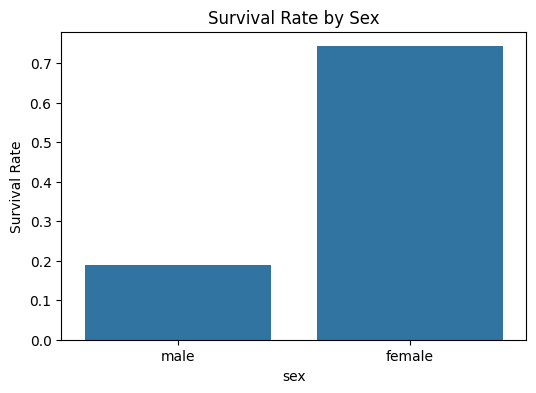

In [3]:
# 성별 생존율 계산
gender_survival = df.groupby('sex')['survived'].mean()
print("성별 생존율: ")
print(gender_survival)

# 시각화
plt.figure(figsize=(6,4))
sns.barplot(x='sex', y='survived', data=df, errorbar = None)
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.show()


# 3. "부자는 살아남았을까?" (객실 등급별 분석)
- 사회적 지위(객실 등급)와 생존의 상관관계를 분석
- 1등석 여성의 생존율과 3등석 남성의 생존율 비교

객실 등급 및 성별 생존율:
sex       female      male
class                     
First   0.968085  0.368852
Second  0.921053  0.157407
Third   0.500000  0.135447


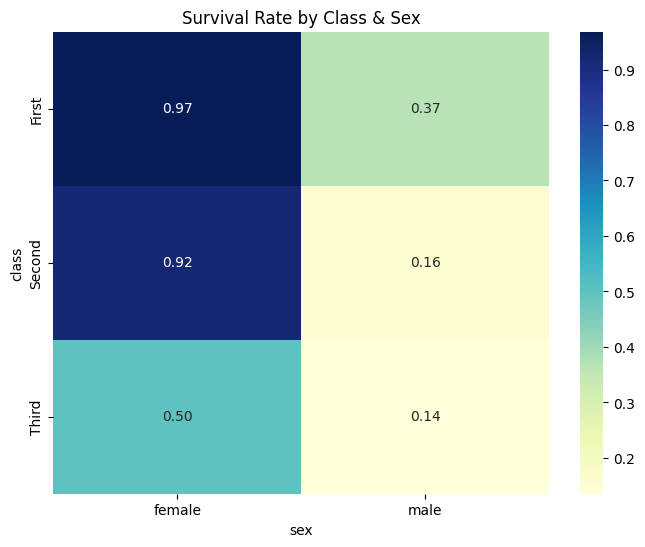

In [7]:
# 객실 등급(class)별 생존율

class_survival = df.pivot_table(index='class', columns='sex', values='survived', aggfunc='mean')
print("객실 등급 및 성별 생존율:")
print(class_survival)

# 히트맵으로 시각화 (색이 진할수록 생존율 높음)
plt.figure(figsize=(8,6))
sns.heatmap(class_survival, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Survival Rate by Class & Sex')
plt.show()